<a href="https://colab.research.google.com/github/hansoe01/data_portfolio_projects/blob/main/Global_TB_Trends_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🌍 Global Tuberculosis (TB) Trends & Seasonality Analysis

### 📌 Project Overview

This project analyzes global tuberculosis (TB) notification data to uncover trends and seasonality patterns across countries and regions.

Using Python for data analysis and visualization, the project transforms raw WHO TB notification data into meaningful insights that support public health decision-making and data-driven analysis.

### 🎯 Objectives
- Analyze TB case trends across countries and regions <br>
- Identify seasonal patterns in TB notifications<br>
- Compare monthly vs quarterly reporting trends<br>
- Evaluate the impact of global events (e.g., COVID-19) on TB reporting<br>
- Assess data quality and reporting consistency<br>

### 🛠️ Tools & Technologies
- Python <br>
- Pandas → data cleaning & transformation <br>
- NumPy → numerical operations <br>
- Matplotlib / Seaborn → visualization <br>
- Jupyter Notebook / Google Colab<br>

### 📊 Key Analysis

**1. 🌍 Global TB Trends**
- Analyzed total TB cases over time <br>
- Identified increasing/decreasing patterns <br>

**2. 🏆 High-Burden Countries**
- Ranked countries by total TB cases<br>
- Highlighted top contributors to global TB burden<br>

**3. 📅 Seasonality Analysis**
- Examined average TB cases by month
- Identified peak months and seasonal patterns

###📂 Dataset

Source: WHO TB Provisional Notifications Dataset:
https://extranet.who.int/tme/generateCSV.asp?ds=provisional_notifications



1. Import Required Libraries and Data Import

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('https://extranet.who.int/tme/generateCSV.asp?ds=provisional_notifications')

In [12]:
df

,country,iso2,iso3,iso_numeric,g_whoregion,year,report_frequency,report_coverage,m_01,m_02,...,m_07,m_08,m_09,m_10,m_11,m_12,q_1,q_2,q_3,q_4
0,Albania,AL,ALB,8,EUR,2020,71,34.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,60.0,79.0,56.0,45.0
1,Albania,AL,ALB,8,EUR,2021,70,34.0,17.0,11.0,...,34.0,22.0,29.0,22.0,21.0,14.0,NaN,NaN,NaN,NaN
2,Albania,AL,ALB,8,EUR,2022,70,34.0,17.0,26.0,...,26.0,25.0,19.0,22.0,22.0,21.0,NaN,NaN,NaN,NaN
3,Albania,AL,ALB,8,EUR,2023,70,34.0,27.0,19.0,...,26.0,35.0,19.0,23.0,23.0,24.0,NaN,NaN,NaN,NaN
4,Albania,AL,ALB,8,EUR,2024,70,34.0,19.0,24.0,...,13.0,23.0,23.0,23.0,20.0,14.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,Zimbabwe,ZW,ZWE,716,AFR,2021,71,34.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3687.0,4122.0,2842.0,NaN
643,Zimbabwe,ZW,ZWE,716,AFR,2022,71,34.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4518.0,4252.0,4347.0,4688.0
644,Zimbabwe,ZW,ZWE,716,AFR,2023,71,34.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4829.0,4819.0,4871.0,NaN
645,Zimbabwe,ZW,ZWE,716,AFR,2024,70,34.0,1817.0,1745.0,...,1792.0,1752.0,1799.0,1906.0,1632.0,1461.0,NaN,NaN,NaN,NaN


2.Data Exploration and Cleaning

In [13]:
print(df.shape)
print(df.columns)
print(df.info())

(647, 24)
Index(['country', 'iso2', 'iso3', 'iso_numeric', 'g_whoregion', 'year',
       'report_frequency', 'report_coverage', 'm_01', 'm_02', 'm_03', 'm_04',
       'm_05', 'm_06', 'm_07', 'm_08', 'm_09', 'm_10', 'm_11', 'm_12', 'q_1',
       'q_2', 'q_3', 'q_4'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647 entries, 0 to 646
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           647 non-null    object 
 1   iso2              641 non-null    object 
 2   iso3              647 non-null    object 
 3   iso_numeric       647 non-null    int64  
 4   g_whoregion       647 non-null    object 
 5   year              647 non-null    int64  
 6   report_frequency  647 non-null    int64  
 7   report_coverage   549 non-null    float64
 8   m_01              435 non-null    float64
 9   m_02              427 non-null    float64
 10  m_03              423 non-null    flo

In [14]:
#Identify Monthly and Quarterly Columns
monthly_cols = [col for col in df.columns if col.startswith('m_')]
quarterly_cols = [col for col in df.columns if col.startswith('q_')]

In [15]:
# Convert Monthly Data Frame
df_monthly = df.melt(
    id_vars=[col for col in df.columns if col not in monthly_cols],
    value_vars=monthly_cols,
    var_name='month',
    value_name='cases'
)

In [16]:
#Extract Month Number
df_monthly['month'] = df_monthly['month'].str.replace('m_', '').astype(int)

In [17]:
#Create datatime column
df_monthly['date'] = pd.to_datetime(
    df_monthly['year'].astype(str) + '-' + df_monthly['month'].astype(str)
)

In [18]:
#Clean cases column
df_monthly['cases'] = pd.to_numeric(df_monthly['cases'], errors='coerce')
df_monthly = df_monthly.dropna(subset=['cases'])

3. Global TB Trends Analysis

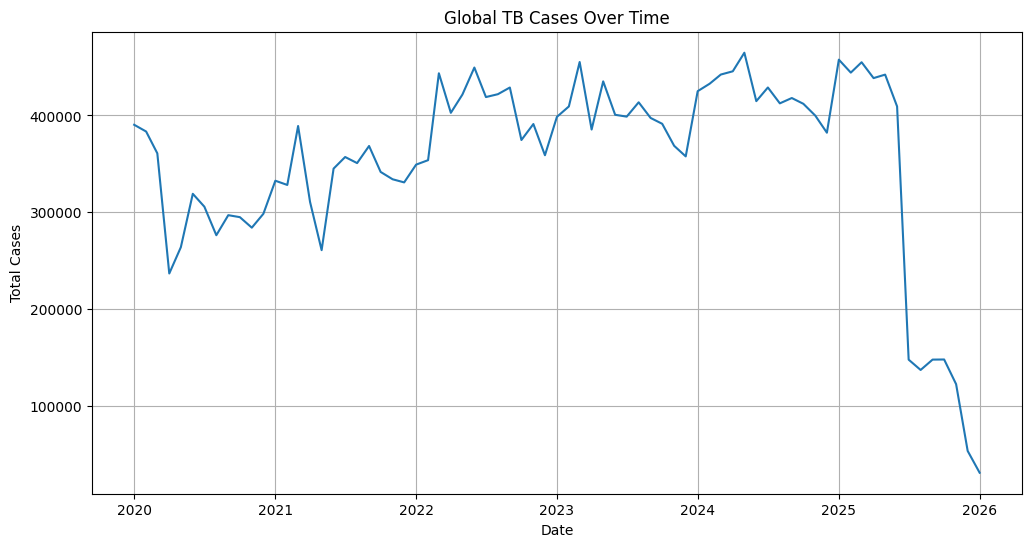

In [19]:
global_trend = df_monthly.groupby('date')['cases'].sum()

plt.figure(figsize=(12,6))
plt.plot(global_trend)
plt.title('Global TB Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid()
plt.show()

4. Top Countries with Highest TB Cases

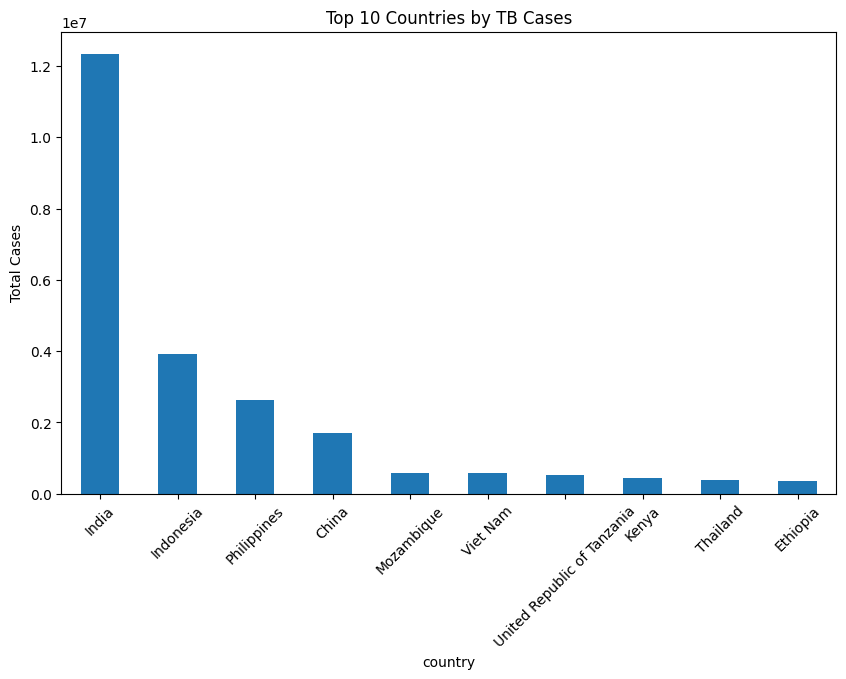

In [20]:
top_countries = (
    df_monthly.groupby('country')['cases']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by TB Cases')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.show()

5. TB Cases Seasonality Analysis

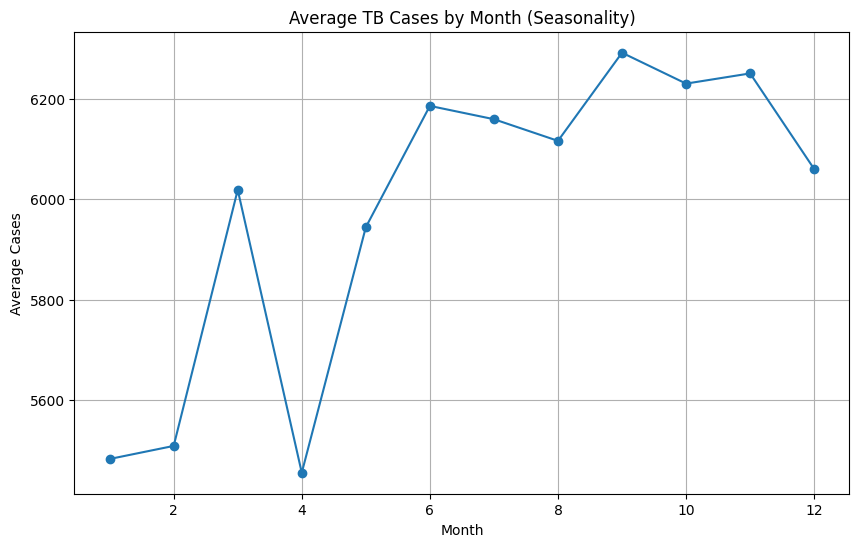

In [21]:
monthly_seasonality = df_monthly.groupby('month')['cases'].mean()

plt.figure(figsize=(10,6))
plt.plot(monthly_seasonality, marker='o')
plt.title('Average TB Cases by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Cases')
plt.grid()
plt.show()

6. TB Cases Quarterly Analysis

In [22]:
df_monthly['quarter'] = df_monthly['date'].dt.quarter

quarterly_trend = df_monthly.groupby(['year', 'quarter'])['cases'].sum().reset_index()

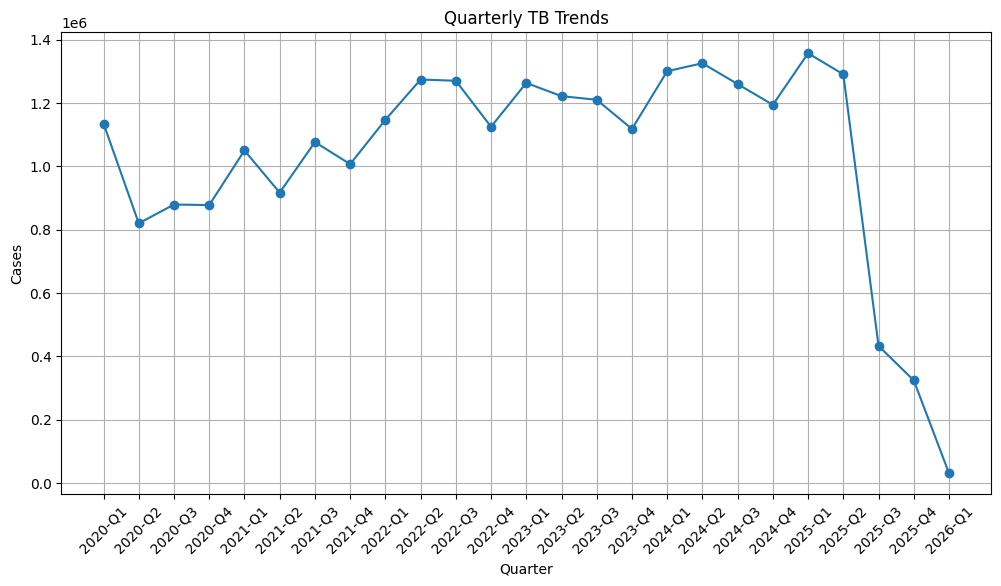

In [23]:
quarterly_trend['period'] = quarterly_trend['year'].astype(str) + '-Q' + quarterly_trend['quarter'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(quarterly_trend['period'], quarterly_trend['cases'], marker='o')
plt.xticks(rotation=45)
plt.title('Quarterly TB Trends')
plt.xlabel('Quarter')
plt.ylabel('Cases')
plt.grid()
plt.show()

7. COVID-19 Impact Analysis

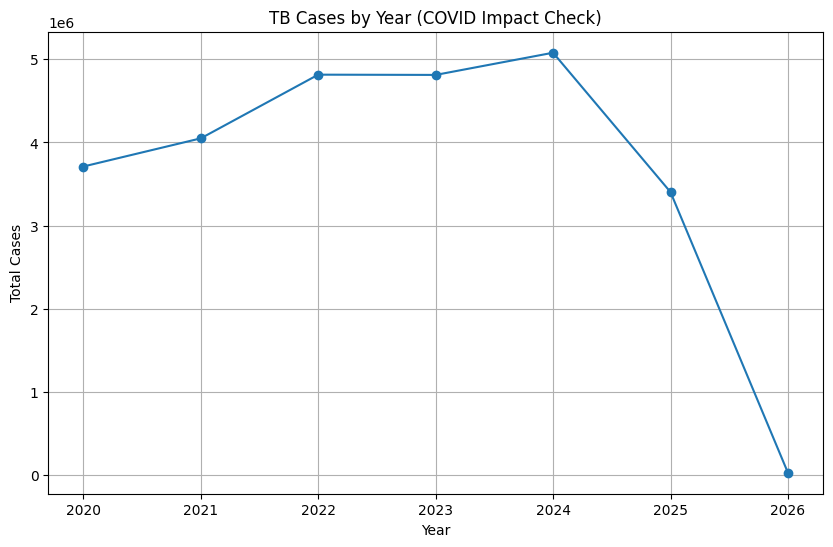

In [26]:
covid_trend = df_monthly.groupby('year')['cases'].sum()

plt.figure(figsize=(10,6))
plt.plot(covid_trend, marker='o')
plt.title('TB Cases by Year (COVID Impact Check)')
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.grid()
plt.show()

###🔑 Key Insights
- TB cases show seasonal variation, with certain months consistently higher
- A small number of countries contribute to a significant portion of global TB burden
- TB notifications show a decline during COVID-19 years, suggesting reporting disruptions


###📌 Recommendations
- Focus interventions on high-burden countries to reduce global TB cases
- Use seasonal trends to plan healthcare resources and awareness campaigns
- Ensure continuous TB reporting during global disruptions (e.g., pandemics)
